# JMAIL Pipeline Processing

Pipeline riproducibile per l'estrazione, il preprocessing e la validazione delle email degli Epstein Files.
Il notebook è organizzato in sei sezioni: estrazione, analisi raw, preprocessing, analisi processata, ispezione visiva delle email, salvataggio.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import dotenv_values

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ENV_PATH = PROJECT_ROOT / ".env"
ENV = dotenv_values(ENV_PATH)


def _resolve(key, default):
    v = ENV.get(key, default)
    p = Path(v)
    return p if p.is_absolute() else PROJECT_ROOT / p


SAMPLE_SIZE = int(ENV.get("PROCESSING_SAMPLE_SIZE", "1000"))

RAW_SAMPLE_PATH = _resolve("DATA_RAW_PATH", "data/raw/") / ENV.get(
    "RAW_EMAILS_SAMPLE_FILENAME", "jmail_emails_sample.parquet"
)
PROCESSED_SAMPLE_PATH = _resolve("DATA_PROCESSED_PATH", "data/processed/") / ENV.get(
    "PROCESSED_EMAILS_SAMPLE_FILENAME", "jmail_emails_processed_sample.parquet"
)

plt.style.use("default")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

print(f"Project root : {PROJECT_ROOT}")
print(f"Sample size  : {SAMPLE_SIZE}")
print(f"Raw path     : {RAW_SAMPLE_PATH}")
print(f"Processed    : {PROCESSED_SAMPLE_PATH}")

Project root : /home/suga/Workspace/Projects/pizza-cluster
Sample size  : 10000
Raw path     : /home/suga/Workspace/Projects/pizza-cluster/data/raw/jmail_emails_sample.parquet
Processed    : /home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet


## 1. Estrazione Dati

Recupera le email dall'API JMAIL e salva il dataset raw in formato Parquet.
Il campione è limitato a `PROCESSING_SAMPLE_SIZE` righe (configurato in `.env`).

In [2]:
from src.utils.data_extraction import run_extraction

extraction_result = run_extraction(env_file=str(ENV_PATH), sample_limit=SAMPLE_SIZE)
extraction_result

{'endpoint': 'v1/emails.parquet',
 'raw_output_path': 'data/raw/jmail_emails.parquet',
 'metadata_output_path': 'data/metadata/jmail_extraction_metadata.json',
 'sample_output_path': 'data/raw/jmail_emails_sample.parquet',
 'row_count': 1783792,
 'column_count': 19}

## 2. Analisi Dati Raw

Carica il campione raw e ne analizza la struttura: numero di righe, colonne e distribuzione dei valori mancanti per variabile.
Il grafico evidenzia in rosso le colonne con oltre il 50% di null, in arancione quelle oltre il 10%.

In [3]:
raw_df = pd.read_parquet(RAW_SAMPLE_PATH)

print(f"Shape: {raw_df.shape[0]:,} righe × {raw_df.shape[1]} colonne")
display(raw_df.dtypes.rename("dtype").to_frame())

Shape: 10,000 righe × 19 colonne


,dtype
id,str
doc_id,str
message_index,int64
sender,str
subject,str
to_recipients,str
cc_recipients,str
bcc_recipients,str
sent_at,str
content_markdown,str


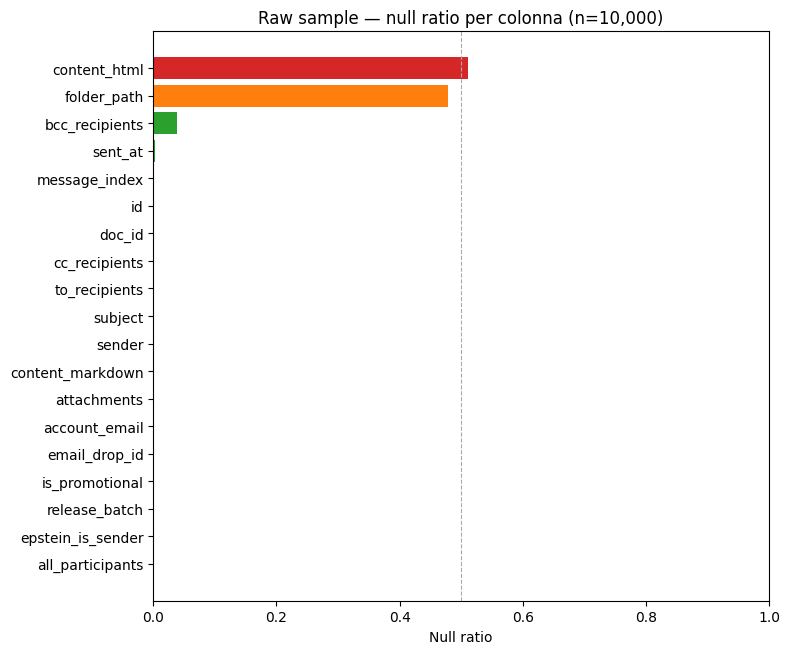

In [4]:
null_ratios = raw_df.isnull().mean().sort_values(ascending=False)

colors = ["#d62728" if r > 0.5 else "#ff7f0e" if r > 0.1 else "#2ca02c" for r in null_ratios]
fig, ax = plt.subplots(figsize=(8, max(4, len(null_ratios) * 0.35)))
ax.barh(null_ratios.index, null_ratios.values, color=colors)
ax.set_xlabel("Null ratio")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.axvline(0.5, color="#aaa", linestyle="--", linewidth=0.8)
ax.set_title(f"Raw sample — null ratio per colonna (n={raw_df.shape[0]:,})")
plt.tight_layout()
plt.show()

## 3. Preprocessing

Esegue la pipeline di cleaning e feature engineering sul campione raw. Le operazioni includono:

- Selezione delle colonne rilevanti
- Rimozione delle email promozionali e dei domini in blacklist
- Normalizzazione del testo e rilevazione disclaimer
- Estrazione di feature di metadato (mittente, destinatari, allegati)
- **Gestione dei thread**: split del corpo email in `content_new` (testo del mittente) e `content_quoted` (thread citato)
- Applicazione del template strutturato per gli embedding, con sezione `THREAD:` separata quando presente

In [5]:
from src.utils.data_processing import run_processing_with_limit

processing_result = run_processing_with_limit(env_file=str(ENV_PATH), limit=SAMPLE_SIZE)
processing_result

{'raw_path': '/home/suga/Workspace/Projects/pizza-cluster/data/raw/jmail_emails.parquet',
 'processed_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet',
 'metadata_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/metadata/jmail_processing_sample_metadata.json',
 'input_rows': 10000,
 'output_rows': 6335,
 'removed_promotional_rows': 3665,
 'removed_empty_text_rows': 0}

## 4. Analisi Dati Processati

Confronta il dataset raw con quello processato: righe rimosse, colonne aggiunte, distribuzione dei null.
Vengono poi analizzati il rilevamento dei disclaimer, la presenza di thread e la variazione della lunghezza del testo prima e dopo la gestione dei thread.

### 4.1 Shape e colonne

In [6]:
processed_df = pd.read_parquet(PROCESSED_SAMPLE_PATH)

rows_in  = raw_df.shape[0]
rows_out = processed_df.shape[0]

summary = pd.DataFrame([
    {"dataset": "raw",       "righe": rows_in,  "colonne": raw_df.shape[1]},
    {"dataset": "processed", "righe": rows_out, "colonne": processed_df.shape[1]},
])
display(summary)
print(f"\nRighe rimosse : {rows_in - rows_out:,} ({(rows_in - rows_out) / rows_in * 100:.1f}%)")

added   = sorted(set(processed_df.columns) - set(raw_df.columns))
removed = sorted(set(raw_df.columns)       - set(processed_df.columns))
if added:   print(f"Colonne aggiunte  : {added}")
if removed: print(f"Colonne rimosse   : {removed}")

,dataset,righe,colonne
0,raw,10000,19
1,processed,6335,34



Righe rimosse : 3,665 (36.6%)
Colonne aggiunte  : ['attachment_count', 'combined_text', 'combined_text_length', 'content_clean', 'content_new', 'content_new_is_short', 'content_quoted', 'has_disclaimer', 'has_redaction', 'has_thread', 'is_epstein_involved', 'person_unknown', 'recipient_count_estimate', 'redaction_count', 'redaction_ratio', 'sender_domain', 'sent_at_datetime', 'subject_clean']
Colonne rimosse   : ['account_email', 'content_html', 'folder_path']


### 4.2 Null ratio — confronto raw vs processed

Mostra l'andamento dei valori mancanti sulle colonne condivise tra i due dataset.

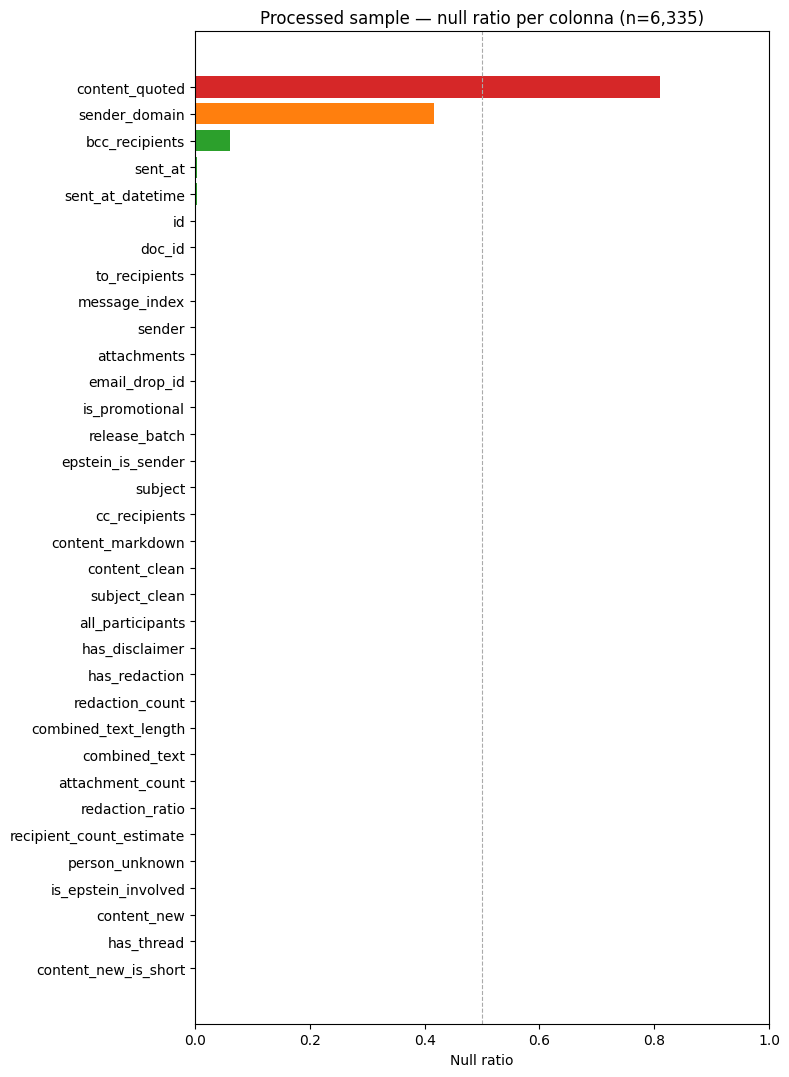

In [7]:
null_proc = processed_df.isnull().mean().sort_values(ascending=False)

colors = ["#d62728" if r > 0.5 else "#ff7f0e" if r > 0.1 else "#2ca02c" for r in null_proc]
fig, ax = plt.subplots(figsize=(8, max(4, len(null_proc) * 0.32)))
ax.barh(null_proc.index, null_proc.values, color=colors)
ax.set_xlabel("Null ratio")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.axvline(0.5, color="#aaa", linestyle="--", linewidth=0.8)
ax.set_title(f"Processed sample — null ratio per colonna (n={rows_out:,})")
plt.tight_layout()
plt.show()

### 4.3 Disclaimer e Thread

Distribuzione delle email con disclaimer legale rilevato e delle email con thread/quote citato.

,metrica,count,%
0,email con disclaimer,1014,16.0%
1,email senza disclaimer,5321,84.0%
2,email con thread (has_thread=True),1202,19.0%
3,email senza thread (has_thread=False),5133,81.0%
4,content_new < 20 chars (is_short=True),946,14.9%
5,content_new normale (is_short=False),5389,85.1%


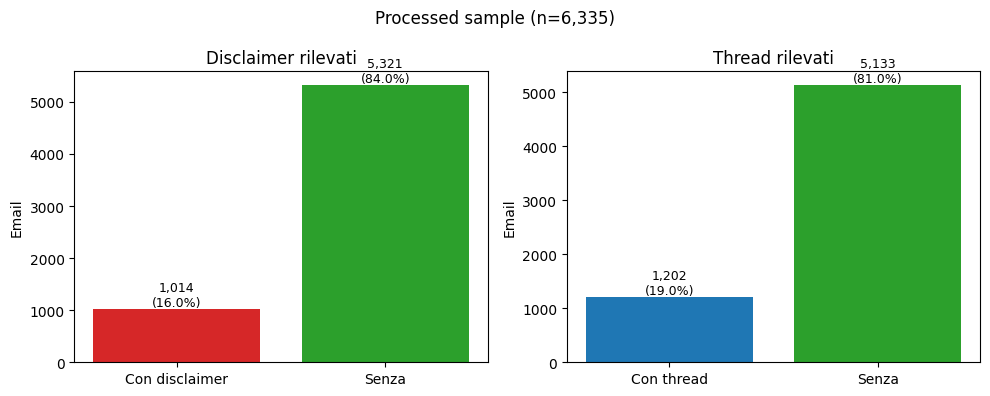

In [8]:
n = len(processed_df)

disc  = processed_df["has_disclaimer"].value_counts().reindex([True, False], fill_value=0)
ht    = processed_df["has_thread"].value_counts().reindex([True, False], fill_value=0)
sh    = processed_df["content_new_is_short"].value_counts().reindex([True, False], fill_value=0)

stats = pd.DataFrame({
    "metrica": [
        "email con disclaimer",
        "email senza disclaimer",
        "email con thread (has_thread=True)",
        "email senza thread (has_thread=False)",
        "content_new < 20 chars (is_short=True)",
        "content_new normale (is_short=False)",
    ],
    "count": [
        int(disc[True]), int(disc[False]),
        int(ht[True]),   int(ht[False]),
        int(sh[True]),   int(sh[False]),
    ],
    "%": [f"{v / n * 100:.1f}%" for v in [
        int(disc[True]), int(disc[False]),
        int(ht[True]),   int(ht[False]),
        int(sh[True]),   int(sh[False]),
    ]],
})
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Con disclaimer", "Senza"], [int(disc[True]), int(disc[False])],
            color=["#d62728", "#2ca02c"])
axes[0].set_title("Disclaimer rilevati")
axes[0].set_ylabel("Email")
for bar, val in zip(axes[0].patches, [int(disc[True]), int(disc[False])]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:,}\n({val/n*100:.1f}%)", ha="center", va="bottom", fontsize=9)

axes[1].bar(["Con thread", "Senza"], [int(ht[True]), int(ht[False])],
            color=["#1f77b4", "#2ca02c"])
axes[1].set_title("Thread rilevati")
axes[1].set_ylabel("Email")
for bar, val in zip(axes[1].patches, [int(ht[True]), int(ht[False])]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:,}\n({val/n*100:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Processed sample (n={n:,})")
plt.tight_layout()
plt.show()

### 4.4 Lunghezza testo prima e dopo la gestione dei thread

`content_clean` contiene il testo completo (incluso il thread citato, normalizzato).
`content_new` contiene solo il contributo del mittente dopo lo split del thread.
Il grafico mostra come la rimozione del thread riduca la lunghezza del testo per le email che ne contengono uno.

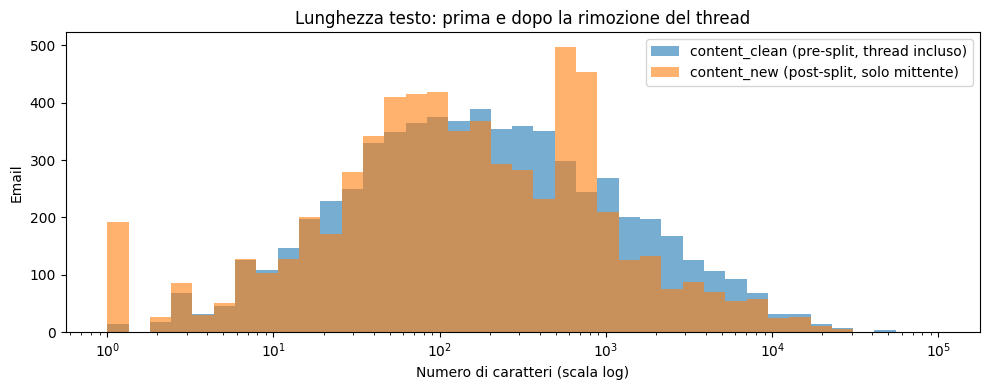

content_clean — mediana: 170 chars | media: 962 chars
content_new   — mediana: 131 chars | media: 687 chars


In [9]:
len_clean = processed_df["content_clean"].fillna("").str.len().clip(lower=1)
len_new   = processed_df["content_new"].fillna("").str.len().clip(lower=1)

bins = np.logspace(0, 5, 40)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(len_clean, bins=bins, alpha=0.6, label="content_clean (pre-split, thread incluso)", color="#1f77b4")
ax.hist(len_new,   bins=bins, alpha=0.6, label="content_new (post-split, solo mittente)",  color="#ff7f0e")
ax.set_xscale("log")
ax.set_xlabel("Numero di caratteri (scala log)")
ax.set_ylabel("Email")
ax.set_title("Lunghezza testo: prima e dopo la rimozione del thread")
ax.legend()
plt.tight_layout()
plt.show()

print(f"content_clean — mediana: {len_clean.median():.0f} chars | media: {len_clean.mean():.0f} chars")
print(f"content_new   — mediana: {len_new.median():.0f} chars | media: {len_new.mean():.0f} chars")

## 5. Struttura delle Email

Ispezione visiva del campo `combined_text` prodotto dalla pipeline.
Si mostrano 5 email normali (senza thread) e 5 email con thread, per verificare il formato del template.

### 5.1 Email normali (senza thread)

Formato atteso: `DATE / FROM / TO / SUBJECT / BODY` senza sezione `THREAD:`.

In [10]:
normal_emails = processed_df[~processed_df["has_thread"]].head(5)

for i, (_, row) in enumerate(normal_emails.iterrows(), 1):
    print(f"{'='*60}")
    print(f"EMAIL NORMALE #{i}")
    print(f"{'='*60}")
    print(row["combined_text"][:800])
    print()

EMAIL NORMALE #1
DATE: 2015-05-07T07:07:33.000Z
FROM: jeffrey E.  <jeevacation@gmail.com>
TO: ["Ehud Barak  <ehbarak1@gmail.com>"]
SUBJECT: Re: Title and subtitle

BODY:
prefer OUR COUNTRY , MY LIFE or MOMENTS

EMAIL NORMALE #2
DATE: 2017-05-18T20:56:45.000Z
FROM: Ryan Andrews <ryan.andrews@sf-email.sharefile.com>
TO: ["<jeeproject@yahoo.com>"]
SUBJECT: Infographic: 5 Ways to Take Center Stage at Work

BODY:
<http://pages.sharefile.com/dc/6-MALPEjw79s-xMyvxHiGZLIqEcLlq--0ISe81Kf7LYea7PplEmZJhwLUdqSQaiZZkJc_XfsEYgKCDfm0jPuY2EV-VoS4zN6Y7aR3swotgh1Ot-00T-nio8AcOHJhi-2E68VylkbkV5_nKSZNybFaw==/ZMheh0wJ70002P09900vPLk> Download Now <http://pages.sharefile.com/dc/6wZe1f5a2jBq0FeFUulJHtKwA1V2VT1oMBPmAoncRklA9TP7HMRUHLTmF-c0b4JDhjSnywwwxD8GpSYP1gQhUPSEoSYQ2BPaAy0MpHL0bxicYPUpwW6KUdpkfxPdF87wf1DHO6j8aCbPllhVXUTsw1vNKz6XNwXnVHAt-4WJVTQ9R3sF07JnjLiJMuzopRcM9FNHS6k0L8uzCcVUrOWHXTvi0lf_vM5V5tjNXKdUltWO5dSCv_KsYspVIkZXV6MnAB6qBPq7SVJtiNoFMRAHNo_o5qw6sctMsiCU6aI7Vtk=/ZMheh0wJ70002P09900vPLk> Get the s

### 5.2 Email con thread

Formato atteso: `DATE / FROM / TO / SUBJECT / BODY` con solo il testo del mittente, seguito dalla sezione `THREAD:` con il contenuto citato.

In [11]:
thread_emails = processed_df[processed_df["has_thread"]].head(5)

for i, (_, row) in enumerate(thread_emails.iterrows(), 1):
    print(f"{'='*60}")
    print(f"EMAIL CON THREAD #{i} | content_new_is_short={row['content_new_is_short']}")
    print(f"{'='*60}")
    print(row["combined_text"][:1000])
    print()

EMAIL CON THREAD #1 | content_new_is_short=False
DATE: 2006-07-10T18:13:50.000Z
FROM: J. Epstein <jeeproject@yahoo.com>
TO: ["Cecilia Steen <cecilia.steen@gmail.com>"]
SUBJECT: Re: Barbro Ehnbom: SALSS 2006

BODY:
i'll try

--- Cecilia Steen <cecilia.steen@gmail.com> wrote:

THREAD:
>  Dear Jeffrey,
> 
> It would be great if you could come over for this
> summit in Stockholm August
> 16 - 18th. You will meet some of the best scientific
> minds in Sweden, we
> know you like that! We would also make a special BBB
> night for you, we would
> all like that!
> 
> All the Best, Always,
> 
> Hej Hej
> 
> 
> Barbro
> *Barbro C. Ehnbom*
> Chairman, Organizing Committee
> www.swedishamericanlifescience.com
> New York: 212 288 3210
> Stockholm: 01146 70 593 8335
> 


__________________________________________________
Do You Yahoo!?
Tired of spam?  Yahoo! Mail has the best spam protection around 
http://mail.yahoo.com 


EMAIL CON THREAD #2 | content_new_is_short=True
DATE: 2007-02-19T20:50:39.000

## 6. Salvataggio Dataset

Il dataset processato è già stato salvato da `run_processing_with_limit` durante la Sezione 3.
Questa sezione conferma il percorso di output, la dimensione del file e le colonne presenti nel Parquet finale.

In [12]:
output_path = PROCESSED_SAMPLE_PATH
file_size_mb = output_path.stat().st_size / (1024 ** 2)

print(f"Path    : {output_path}")
print(f"Size    : {file_size_mb:.2f} MB")
print(f"Shape   : {processed_df.shape[0]:,} righe × {processed_df.shape[1]} colonne")
print()
print("Colonne nel dataset finale:")
for col in sorted(processed_df.columns):
    dtype = str(processed_df[col].dtype)
    null_pct = processed_df[col].isnull().mean() * 100
    print(f"  {col:<35} {dtype:<15} null: {null_pct:.1f}%")

Path    : /home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet
Size    : 14.76 MB
Shape   : 6,335 righe × 34 colonne

Colonne nel dataset finale:
  all_participants                    str             null: 0.0%
  attachment_count                    Int64           null: 0.0%
  attachments                         int64           null: 0.0%
  bcc_recipients                      str             null: 6.0%
  cc_recipients                       str             null: 0.0%
  combined_text                       str             null: 0.0%
  combined_text_length                Int64           null: 0.0%
  content_clean                       str             null: 0.0%
  content_markdown                    str             null: 0.0%
  content_new                         str             null: 0.0%
  content_new_is_short                bool            null: 0.0%
  content_quoted                      str             null: 81.0%
  doc_id                     